In [1]:
# Clustering setup and shared utilities
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

OUTPUT_DIR = Path("outputs")
PCA2D_PATH = OUTPUT_DIR / "all_subjects_pca2d_firstocc.npy"
META_PATH = OUTPUT_DIR / "all_subjects_meta_firstocc.npz"


def _safe_cluster_metrics(x: np.ndarray, labels: np.ndarray) -> tuple[float, float, float]:
    uniq = np.unique(labels)
    if uniq.size < 2 or uniq.size >= x.shape[0]:
        return float("nan"), float("nan"), float("nan")
    return (
        float(silhouette_score(x, labels)),
        float(davies_bouldin_score(x, labels)),
        float(calinski_harabasz_score(x, labels)),
    )

In [2]:
K_VALUES = list(range(2, 11))

# Set to None to auto-select K by max silhouette score
# Set to a specific int (e.g., 3) to override and use that K directly
SELECTED_K_KMEANS = 5  # e.g., set to 3 to force k=3 for k-means
SELECTED_K_SPECTRAL = 5  # e.g., set to 3 to force k=3 for spectral

# K-means parameters
KMEANS_N_INIT = 20  # Number of times to run K-means with different init
KMEANS_RANDOM_STATE = 42

# Spectral Clustering parameters
SPECTRAL_N_NEIGHBORS = None  # Auto-computed if None; set to int to override

# Random seed for reproducibility
RANDOM_STATE = 42

print("=" * 70)
print("CLUSTERING CONFIG")
print("=" * 70)
print(f"K sweep range: {K_VALUES}")
print(f"K-means: selected_k={SELECTED_K_KMEANS} (None=auto), n_init={KMEANS_N_INIT}")
print(f"Spectral: selected_k={SELECTED_K_SPECTRAL} (None=auto)")
print(f"Random state: {RANDOM_STATE}")
print("=" * 70)


CLUSTERING CONFIG
K sweep range: [2, 3, 4, 5, 6, 7, 8, 9, 10]
K-means: selected_k=5 (None=auto), n_init=20
Spectral: selected_k=5 (None=auto)
Random state: 42


## 1) Load merged all-subject dataset

This cell loads the merged PCA-2D coordinates and metadata produced in the autoencoder notebook aggregation cell.

If this fails with missing files, run the final aggregation cell in `autoencoder_main_1.ipynb` first.

Loaded samples: 1043
Feature dimension: 2
K values used: [2, 3, 4, 5, 6, 7, 8, 9, 10]
First 10 subjects: ['OAS30001', 'OAS30002', 'OAS30003', 'OAS30004', 'OAS30005', 'OAS30006', 'OAS30030', 'OAS30031', 'OAS30032', 'OAS30033']


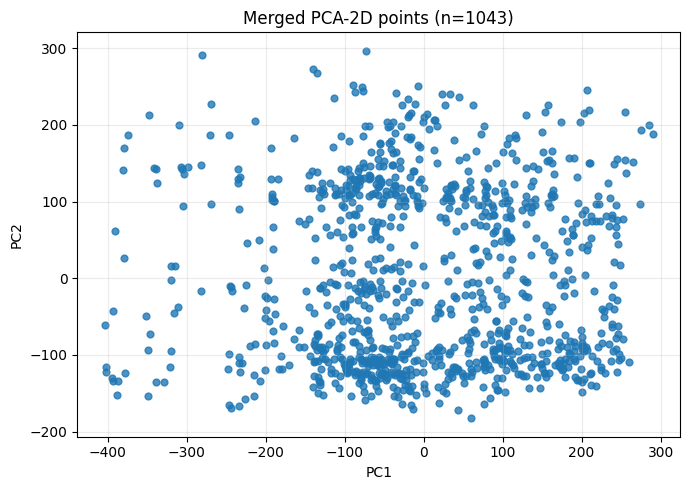

In [3]:
if not PCA2D_PATH.exists() or not META_PATH.exists():
    raise FileNotFoundError(
        "Merged PCA/meta files not found. Run the final aggregation cell in autoencoder_main_1.ipynb first."
    )

X = np.load(PCA2D_PATH).astype(np.float32)
with np.load(META_PATH, allow_pickle=True) as meta:
    subject_id = np.array(meta["subject_id"]).astype(str)
    seed = np.array(meta["seed"], dtype=np.int64) if "seed" in meta else np.full(len(subject_id), -1, dtype=np.int64)
    fg_ratio = np.array(meta["fg_ratio"], dtype=np.float32) if "fg_ratio" in meta else np.full(len(subject_id), np.nan, dtype=np.float32)

if X.ndim != 2 or X.shape[1] != 2:
    raise ValueError(f"Expected PCA-2D matrix of shape (N,2), but got {X.shape}")
if X.shape[0] != subject_id.shape[0]:
    raise ValueError(f"Row mismatch: X has {X.shape[0]} rows, subject_id has {subject_id.shape[0]}")

if np.isnan(X).any() or np.isinf(X).any():
    raise ValueError("X contains NaN or Inf values.")

K_VALUES = [k for k in K_VALUES if 2 <= k < X.shape[0]]
if not K_VALUES:
    raise ValueError(f"Not enough samples for clustering. Need at least 3 samples, found {X.shape[0]}.")

print("Loaded samples:", X.shape[0])
print("Feature dimension:", X.shape[1])
print("K values used:", K_VALUES)
print("First 10 subjects:", subject_id[:10].tolist())

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=24, alpha=0.8)
plt.title(f"Merged PCA-2D points (n={X.shape[0]})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Metadata match key: SOURCE_SUBJECT
Matched rows for age: 1038/1043
Matched rows for sex: 1038/1043
Matched rows for cdr: 1038/1043


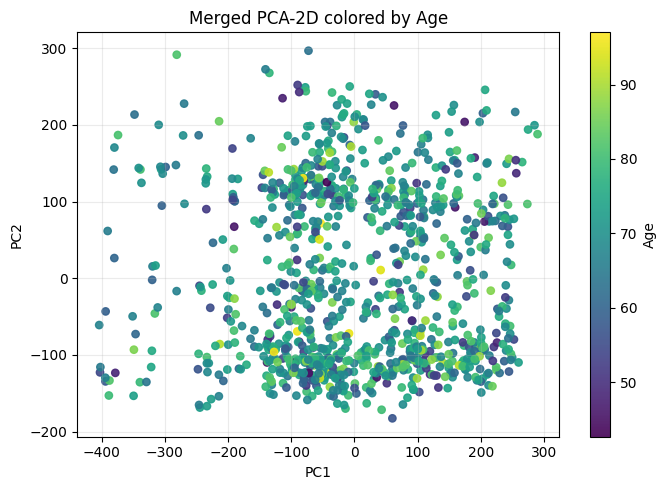

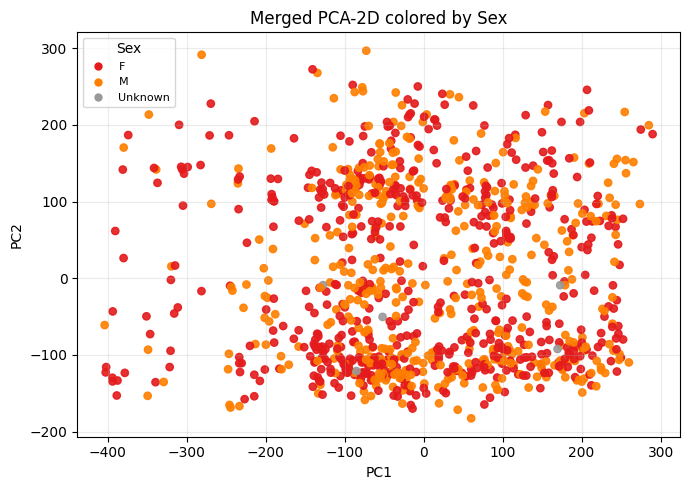

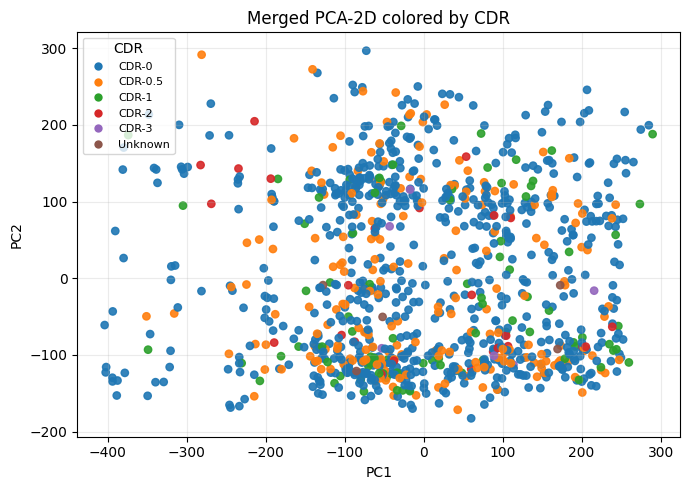

In [4]:
import re

METADATA_CSV_PATH = Path("metadata.csv")
if not METADATA_CSV_PATH.exists():
    raise FileNotFoundError(f"metadata.csv not found at: {METADATA_CSV_PATH}")

meta_df = pd.read_csv(METADATA_CSV_PATH, sep=";")
required_meta_cols = {"SUBJECT_ID", "SOURCE_SUBJECT", "SEX", "AGE", "DIAGNOSIS_SUBTYPE"}
missing_cols = required_meta_cols - set(meta_df.columns)
if missing_cols:
    raise ValueError(f"metadata.csv is missing required columns: {sorted(missing_cols)}")

plot_df = pd.DataFrame(
    {
        "subject_id": subject_id.astype(str),
        "pc1": X[:, 0],
        "pc2": X[:, 1],
    }
)

# Match using session-level IDs if present, else fallback to base subject ID.
use_session_id_match = plot_df["subject_id"].str.contains(r"_ses-", regex=True, na=False).any()

if use_session_id_match:
    join_right = "SUBJECT_ID"
    meta_match = meta_df.drop_duplicates(subset=[join_right], keep="first").copy()
else:
    join_right = "SOURCE_SUBJECT"
    # Keep first occurrence to align with first-occurrence merged PCA export.
    meta_match = meta_df.sort_values("SUBJECT_ID").drop_duplicates(subset=[join_right], keep="first").copy()

meta_match = meta_match.rename(
    columns={
        join_right: "subject_id",
        "AGE": "age",
        "SEX": "sex",
        "DIAGNOSIS_SUBTYPE": "cdr_raw",
    }
)

meta_match["subject_id"] = meta_match["subject_id"].astype(str)
meta_match["age"] = pd.to_numeric(meta_match["age"], errors="coerce")
meta_match["sex"] = meta_match["sex"].astype(str).str.strip().replace({"": "Unknown", "nan": "Unknown"}).fillna("Unknown")

cdr_extracted = meta_match["cdr_raw"].astype(str).str.extract(r"(CDR-[0-9.]+)", expand=False)
meta_match["cdr"] = cdr_extracted.fillna(meta_match["cdr_raw"].astype(str)).replace({"": "Unknown", "nan": "Unknown"}).fillna("Unknown")

plot_meta = plot_df.merge(
    meta_match[["subject_id", "age", "sex", "cdr"]],
    on="subject_id",
    how="left",
)

n_total = len(plot_meta)
n_age = int(plot_meta["age"].notna().sum())
n_sex = int(plot_meta["sex"].notna().sum())
n_cdr = int(plot_meta["cdr"].notna().sum())
print(f"Metadata match key: {join_right}")
print(f"Matched rows for age: {n_age}/{n_total}")
print(f"Matched rows for sex: {n_sex}/{n_total}")
print(f"Matched rows for cdr: {n_cdr}/{n_total}")

# 1) Age (continuous)
plt.figure(figsize=(7, 5))
sc_age = plt.scatter(
    plot_meta["pc1"],
    plot_meta["pc2"],
    c=plot_meta["age"],
    cmap="viridis",
    s=28,
    alpha=0.9,
)
plt.colorbar(sc_age, label="Age")
plt.title("Merged PCA-2D colored by Age")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 2) Sex (categorical)
sex_series = plot_meta["sex"].fillna("Unknown").astype(str)
sex_order = [x for x in ["F", "M", "Unknown"] if x in set(sex_series)]
sex_order += [x for x in sorted(set(sex_series)) if x not in sex_order]
sex_palette = plt.get_cmap("Set1")(np.linspace(0, 1, max(3, len(sex_order))))
sex_color_map = {k: sex_palette[i] for i, k in enumerate(sex_order)}
sex_colors = sex_series.map(sex_color_map)

plt.figure(figsize=(7, 5))
plt.scatter(plot_meta["pc1"], plot_meta["pc2"], c=sex_colors, s=28, alpha=0.9)
sex_handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", markerfacecolor=sex_color_map[k], markeredgecolor="none", label=k)
    for k in sex_order
]
plt.legend(handles=sex_handles, title="Sex", fontsize=8)
plt.title("Merged PCA-2D colored by Sex")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 3) CDR (categorical)
cdr_series = plot_meta["cdr"].fillna("Unknown").astype(str)


def _cdr_sort_key(label: str) -> tuple[int, float | str]:
    m = re.search(r"CDR-([0-9.]+)", str(label))
    if m:
        return (0, float(m.group(1)))
    return (1, str(label))


cdr_order = sorted(set(cdr_series), key=_cdr_sort_key)
cdr_palette = plt.get_cmap("tab10")(np.linspace(0, 1, max(10, len(cdr_order))))
cdr_color_map = {k: cdr_palette[i] for i, k in enumerate(cdr_order)}
cdr_colors = cdr_series.map(cdr_color_map)

plt.figure(figsize=(7, 5))
plt.scatter(plot_meta["pc1"], plot_meta["pc2"], c=cdr_colors, s=28, alpha=0.9)
cdr_handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", markerfacecolor=cdr_color_map[k], markeredgecolor="none", label=k)
    for k in cdr_order
]
plt.legend(handles=cdr_handles, title="CDR", fontsize=8, loc="best")
plt.title("Merged PCA-2D colored by CDR")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 1b) Metadata color-coded PCA views (Age, Sex, CDR)

These plots color the same merged PCA points using demographic/clinical fields from `metadata.csv`.

Matching strategy:
- If merged `subject_id` contains session info (`_ses-...`), match with `SUBJECT_ID`.
- Otherwise, match base subject IDs with `SOURCE_SUBJECT`.

## 2) K-means clustering sweep and evaluation

We test multiple cluster counts and report:
- Inertia (elbow criterion)
- Silhouette score (higher is better)
- Davies-Bouldin index (lower is better)
- Calinski-Harabasz index (higher is better)

In [4]:
kmeans_rows = []
kmeans_labels_by_k: dict[int, np.ndarray] = {}

for k in K_VALUES:
    model = KMeans(n_clusters=k, n_init=KMEANS_N_INIT, random_state=RANDOM_STATE)
    labels = model.fit_predict(X)
    sil, dbi, chi = _safe_cluster_metrics(X, labels)

    row = {
        "algorithm": "kmeans",
        "k": int(k),
        "inertia": float(model.inertia_),
        "silhouette": sil,
        "davies_bouldin": dbi,
        "calinski_harabasz": chi,
    }
    kmeans_rows.append(row)
    kmeans_labels_by_k[int(k)] = labels

kmeans_df = pd.DataFrame(kmeans_rows).sort_values("k").reset_index(drop=True)
print("K-means metric table")
print(kmeans_df.to_string(index=False))

# Use SELECTED_K_KMEANS if set, otherwise auto-select by max silhouette
if SELECTED_K_KMEANS is not None:
    best_k_kmeans = SELECTED_K_KMEANS
    print(f"\n[CONFIG] Using manual K-means k={best_k_kmeans}")
else:
    best_k_kmeans = int(kmeans_df.loc[kmeans_df["silhouette"].idxmax(), "k"])
    print(f"\n[AUTO] Selected K-means k by max silhouette: {best_k_kmeans}")

kmeans_final = KMeans(n_clusters=best_k_kmeans, n_init=KMEANS_N_INIT, random_state=RANDOM_STATE)
kmeans_final_labels = kmeans_final.fit_predict(X)

K-means metric table
algorithm  k     inertia  silhouette  davies_bouldin  calinski_harabasz
   kmeans  2 20091954.00    0.369489        1.102712         703.277817
   kmeans  3 12835555.00    0.422526        0.788637         843.878837
   kmeans  4  9205370.00    0.433640        0.779641         920.268712
   kmeans  5  6822111.00    0.450218        0.766243        1021.136415
   kmeans  6  5795128.00    0.450597        0.740731         997.449634
   kmeans  7  4938399.50    0.426504        0.757680        1004.422588
   kmeans  8  4280389.50    0.414203        0.804504        1015.053051
   kmeans  9  3698342.75    0.413893        0.798394        1047.300483
   kmeans 10  3322718.50    0.406536        0.837787        1048.146316

[CONFIG] Using manual K-means k=5


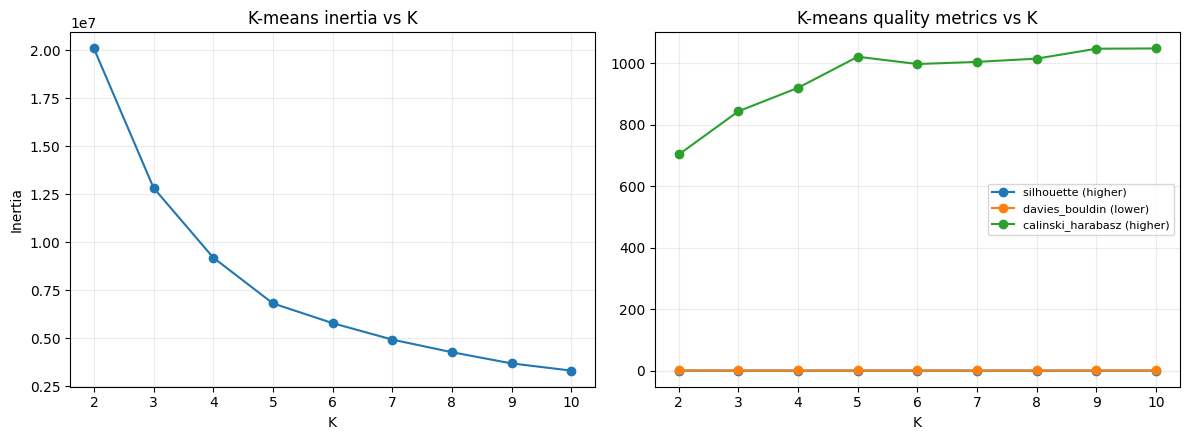

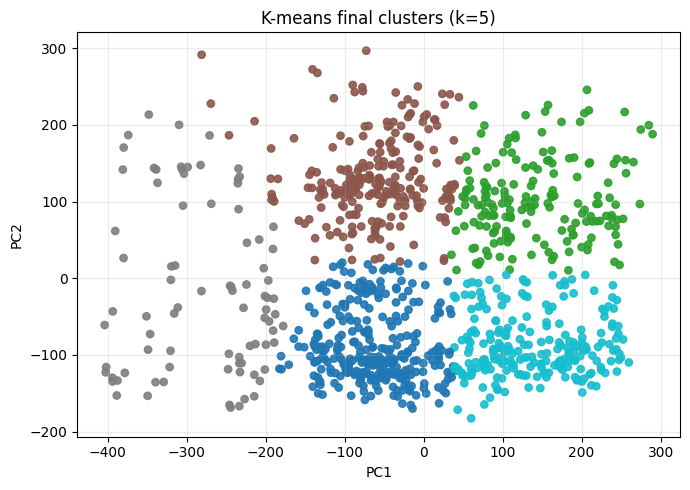

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(kmeans_df["k"], kmeans_df["inertia"], marker="o")
axes[0].set_title("K-means inertia vs K")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.25)

axes[1].plot(kmeans_df["k"], kmeans_df["silhouette"], marker="o", label="silhouette (higher)")
axes[1].plot(kmeans_df["k"], kmeans_df["davies_bouldin"], marker="o", label="davies_bouldin (lower)")
axes[1].plot(kmeans_df["k"], kmeans_df["calinski_harabasz"], marker="o", label="calinski_harabasz (higher)")
axes[1].set_title("K-means quality metrics vs K")
axes[1].set_xlabel("K")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=kmeans_final_labels, cmap="tab10", s=28, alpha=0.9)
plt.title(f"K-means final clusters (k={best_k_kmeans})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 3) Spectral Clustering sweep and evaluation

Spectral Clustering has no inertia value, so we evaluate with:
- Silhouette score
- Davies-Bouldin index
- Calinski-Harabasz index

In [6]:
spectral_rows = []
spectral_labels_by_k: dict[int, np.ndarray] = {}

for k in K_VALUES:
    n_neighbors_val = SPECTRAL_N_NEIGHBORS if SPECTRAL_N_NEIGHBORS is not None else max(2, min(10, X.shape[0] - 1))
    model = SpectralClustering(
        n_clusters=k,
        affinity="nearest_neighbors",
        n_neighbors=n_neighbors_val,
        assign_labels="kmeans",
        random_state=RANDOM_STATE,
    )
    labels = model.fit_predict(X)
    sil, dbi, chi = _safe_cluster_metrics(X, labels)

    row = {
        "algorithm": "spectral",
        "k": int(k),
        "inertia": float("nan"),
        "silhouette": sil,
        "davies_bouldin": dbi,
        "calinski_harabasz": chi,
    }
    spectral_rows.append(row)
    spectral_labels_by_k[int(k)] = labels

spectral_df = pd.DataFrame(spectral_rows).sort_values("k").reset_index(drop=True)
print("Spectral metric table")
print(spectral_df.to_string(index=False))

# Use SELECTED_K_SPECTRAL if set, otherwise auto-select by max silhouette
if SELECTED_K_SPECTRAL is not None:
    best_k_spectral = SELECTED_K_SPECTRAL
    print(f"\n[CONFIG] Using manual Spectral k={best_k_spectral}")
else:
    best_k_spectral = int(spectral_df.loc[spectral_df["silhouette"].idxmax(), "k"])
    print(f"\n[AUTO] Selected Spectral k by max silhouette: {best_k_spectral}")

n_neighbors_val = SPECTRAL_N_NEIGHBORS if SPECTRAL_N_NEIGHBORS is not None else max(2, min(10, X.shape[0] - 1))
spectral_final = SpectralClustering(
    n_clusters=best_k_spectral,
    affinity="nearest_neighbors",
    n_neighbors=n_neighbors_val,
    assign_labels="kmeans",
    random_state=RANDOM_STATE,
)
spectral_final_labels = spectral_final.fit_predict(X)

Spectral metric table
algorithm  k  inertia  silhouette  davies_bouldin  calinski_harabasz
 spectral  2      NaN    0.367957        1.103141         698.812626
 spectral  3      NaN    0.400351        0.868700         744.159676
 spectral  4      NaN    0.391358        0.906002         734.120202
 spectral  5      NaN    0.440513        0.801872         986.953041
 spectral  6      NaN    0.390051        0.792127         896.554154
 spectral  7      NaN    0.357173        0.919663         836.667364
 spectral  8      NaN    0.358518        0.771491         819.674435
 spectral  9      NaN    0.355784        0.830572         844.078807
 spectral 10      NaN    0.365264        0.807077         910.713660

[CONFIG] Using manual Spectral k=5


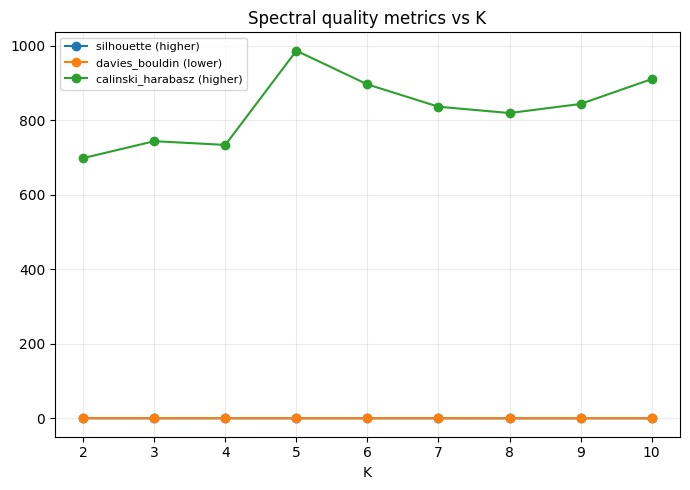

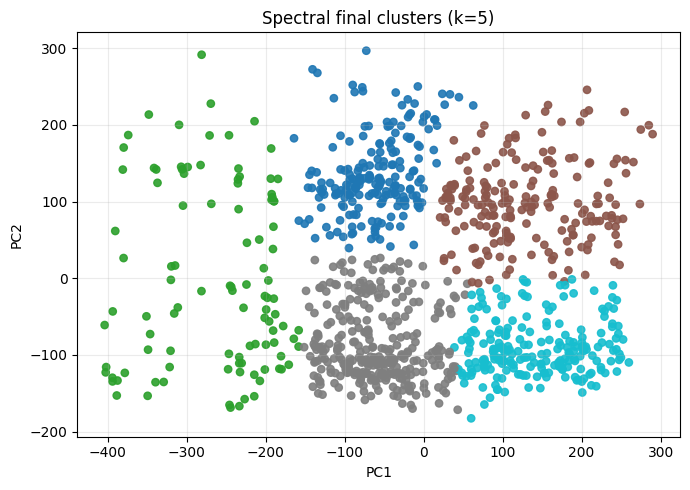

In [7]:
plt.figure(figsize=(7, 5))
plt.plot(spectral_df["k"], spectral_df["silhouette"], marker="o", label="silhouette (higher)")
plt.plot(spectral_df["k"], spectral_df["davies_bouldin"], marker="o", label="davies_bouldin (lower)")
plt.plot(spectral_df["k"], spectral_df["calinski_harabasz"], marker="o", label="calinski_harabasz (higher)")
plt.title("Spectral quality metrics vs K")
plt.xlabel("K")
plt.grid(alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=spectral_final_labels, cmap="tab10", s=28, alpha=0.9)
plt.title(f"Spectral final clusters (k={best_k_spectral})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 4) Compare methods and export results

This cell saves metric tables, label assignments, and a side-by-side plot for final selected K values.

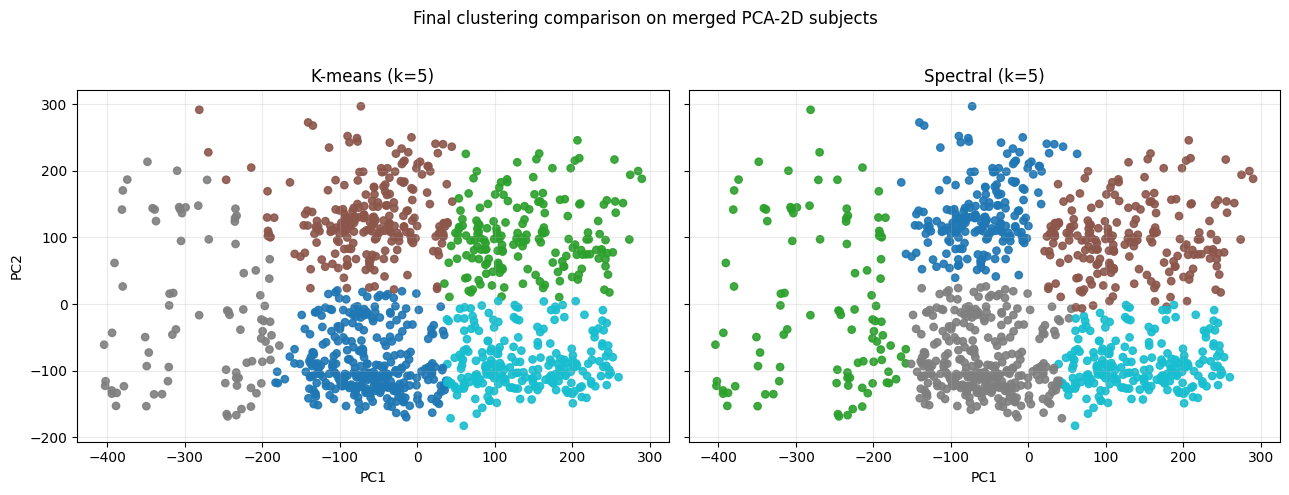

Saved: outputs\kmeans_metrics_pca2d.csv
Saved: outputs\spectral_metrics_pca2d.csv
Saved: outputs\cluster_method_comparison_pca2d.csv
Saved: outputs\cluster_labels_final_pca2d.csv
Saved: outputs\cluster_comparison_final_pca2d.png

Final method summary
algorithm  selected_k  silhouette  davies_bouldin  calinski_harabasz   inertia
   kmeans           5    0.450218        0.766243        1021.136415 6822111.0
 spectral           5    0.440513        0.801872         986.953041       NaN


In [8]:
kmeans_csv = OUTPUT_DIR / "kmeans_metrics_pca2d.csv"
spectral_csv = OUTPUT_DIR / "spectral_metrics_pca2d.csv"
summary_csv = OUTPUT_DIR / "cluster_method_comparison_pca2d.csv"
labels_csv = OUTPUT_DIR / "cluster_labels_final_pca2d.csv"
comparison_plot = OUTPUT_DIR / "cluster_comparison_final_pca2d.png"

kmeans_df.to_csv(kmeans_csv, index=False)
spectral_df.to_csv(spectral_csv, index=False)

summary_df = pd.DataFrame(
    [
        {
            "algorithm": "kmeans",
            "selected_k": best_k_kmeans,
            "silhouette": float(_safe_cluster_metrics(X, kmeans_final_labels)[0]),
            "davies_bouldin": float(_safe_cluster_metrics(X, kmeans_final_labels)[1]),
            "calinski_harabasz": float(_safe_cluster_metrics(X, kmeans_final_labels)[2]),
            "inertia": float(kmeans_final.inertia_),
        },
        {
            "algorithm": "spectral",
            "selected_k": best_k_spectral,
            "silhouette": float(_safe_cluster_metrics(X, spectral_final_labels)[0]),
            "davies_bouldin": float(_safe_cluster_metrics(X, spectral_final_labels)[1]),
            "calinski_harabasz": float(_safe_cluster_metrics(X, spectral_final_labels)[2]),
            "inertia": float("nan"),
        },
    ]
)
summary_df.to_csv(summary_csv, index=False)

labels_df = pd.DataFrame(
    {
        "subject_id": subject_id,
        "seed_kept": seed,
        "fg_ratio": fg_ratio,
        "pc1": X[:, 0],
        "pc2": X[:, 1],
        "kmeans_label": kmeans_final_labels,
        "spectral_label": spectral_final_labels,
    }
).sort_values("subject_id").reset_index(drop=True)
labels_df.to_csv(labels_csv, index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

axes[0].scatter(X[:, 0], X[:, 1], c=kmeans_final_labels, cmap="tab10", s=28, alpha=0.9)
axes[0].set_title(f"K-means (k={best_k_kmeans})")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(alpha=0.25)

axes[1].scatter(X[:, 0], X[:, 1], c=spectral_final_labels, cmap="tab10", s=28, alpha=0.9)
axes[1].set_title(f"Spectral (k={best_k_spectral})")
axes[1].set_xlabel("PC1")
axes[1].grid(alpha=0.25)

fig.suptitle("Final clustering comparison on merged PCA-2D subjects")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(comparison_plot, dpi=160)
plt.show()
plt.close(fig)

print("Saved:", kmeans_csv)
print("Saved:", spectral_csv)
print("Saved:", summary_csv)
print("Saved:", labels_csv)
print("Saved:", comparison_plot)
print("\nFinal method summary")
print(summary_df.to_string(index=False))